In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cuda
Test samples: 750
✅ Model loaded


100%|██████████| 188/188 [00:25<00:00,  7.50it/s]



🎯 FINAL RESULTS
Test Loss  : 0.1103
Accuracy   : 0.9523
Mean IoU   : 0.6808


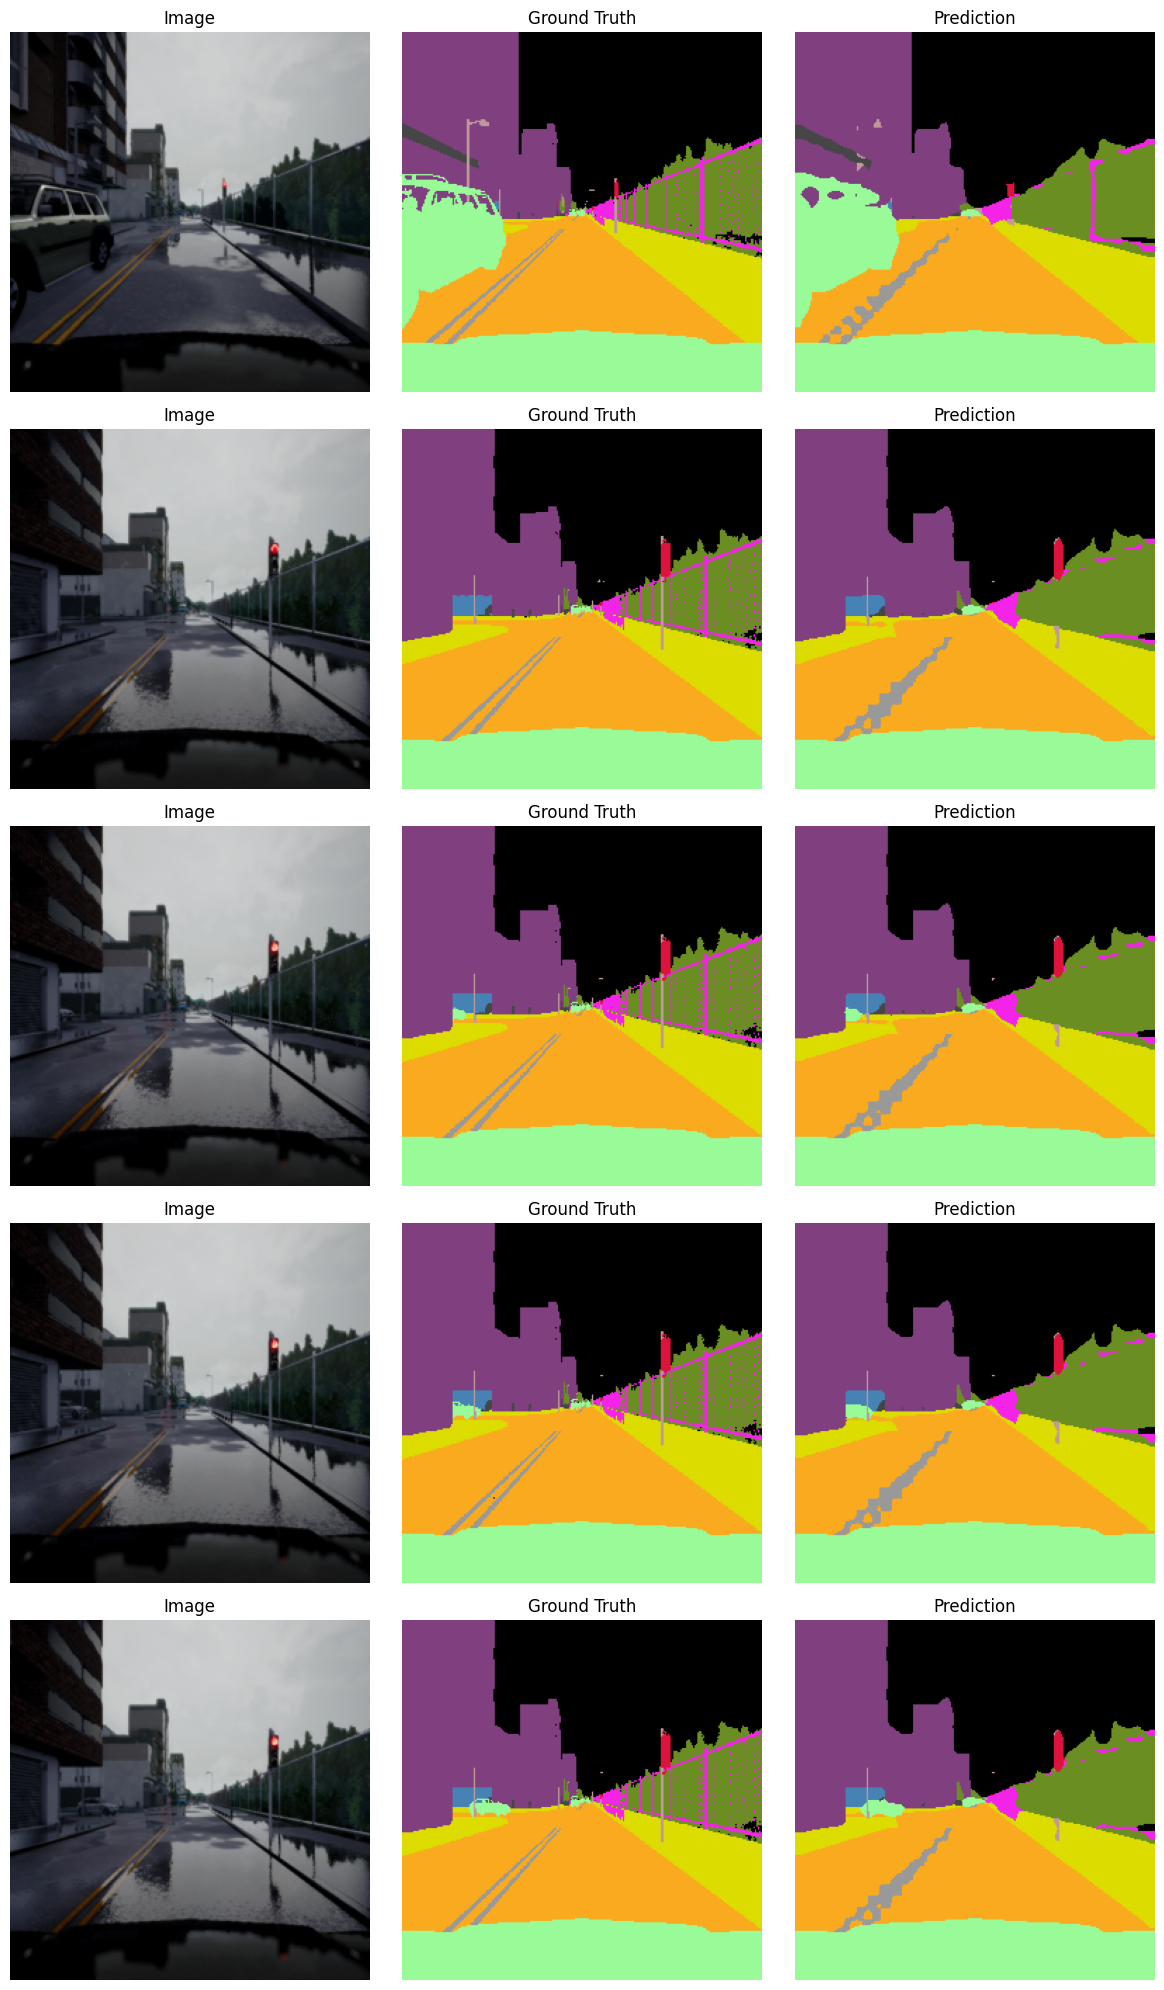

In [9]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================
# CONFIG
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 13
IMAGE_SIZE = 256

MODEL_PATH = "/kaggle/input/models/aniket1234555555/deeplabv3/pytorch/default/1/deeplabv3_best.pth"
TEST_DIR = "/kaggle/working/lyft_split/test"

print("Using device:", DEVICE)

# =========================
# DATASET (MATCH TRAINING)
# =========================
class SegDataset(Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "images")
        self.mask_dir = os.path.join(root, "masks")
        self.images = sorted(os.listdir(self.img_dir))

        self.transform = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        image = self.transform(image)

        # ✅ SAME AS TRAINING
        mask = np.array(mask)
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]

        mask = Image.fromarray(mask).resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)
        mask = torch.from_numpy(np.array(mask)).long()

        return image, mask

# =========================
# LOAD DATA
# =========================
test_dataset = SegDataset(TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

print("Test samples:", len(test_dataset))

# =========================
# MODEL
# =========================
model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=None,
    weights_backbone=None
)

model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, 1)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("✅ Model loaded")

# =========================
# LOSS + METRICS
# =========================
criterion = nn.CrossEntropyLoss()

def compute_metrics(preds, labels):
    preds = preds.view(-1)
    labels = labels.view(-1)

    acc = (preds == labels).sum().item() / labels.numel()

    ious = []
    for cls in range(NUM_CLASSES):
        pred_i = preds == cls
        label_i = labels == cls

        inter = (pred_i & label_i).sum().item()
        union = (pred_i | label_i).sum().item()

        if union == 0:
            continue
        ious.append(inter / union)

    return acc, np.mean(ious)

# =========================
# TEST LOOP
# =========================
test_loss = 0
test_acc, test_iou = [], []

with torch.no_grad():
    for images, masks in tqdm(test_loader):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)['out']
        loss = criterion(outputs, masks)

        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        acc, iou = compute_metrics(preds, masks)
        test_acc.append(acc)
        test_iou.append(iou)

# =========================
# RESULTS
# =========================
test_loss /= len(test_loader)

print("\n🎯 FINAL RESULTS")
print(f"Test Loss  : {test_loss:.4f}")
print(f"Accuracy   : {np.mean(test_acc):.4f}")
print(f"Mean IoU   : {np.mean(test_iou):.4f}")

# =========================
# COLOR MAP (FOR VISUALIZATION)
# =========================
def decode_segmap(mask):
    label_colors = np.array([
        (0, 0, 0),
        (128, 64, 128),
        (244, 35, 232),
        (70, 70, 70),
        (102, 102, 156),
        (190, 153, 153),
        (153, 153, 153),
        (250, 170, 30),
        (220, 220, 0),
        (107, 142, 35),
        (152, 251, 152),
        (70, 130, 180),
        (220, 20, 60)
    ])
    return label_colors[mask]

# =========================
# VISUALIZATION
# =========================
def visualize_predictions(model, dataset, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        image, mask = dataset[i]

        input_tensor = image.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)['out']
            pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

        # Unnormalize image
        img = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i][0].imshow(img)
        axes[i][0].set_title("Image")

        axes[i][1].imshow(decode_segmap(mask.numpy()))
        axes[i][1].set_title("Ground Truth")

        axes[i][2].imshow(decode_segmap(pred))
        axes[i][2].set_title("Prediction")

        for j in range(3):
            axes[i][j].axis("off")

    plt.tight_layout()
    plt.show()

# =========================
# RUN VISUALIZATION
# =========================
visualize_predictions(model, test_dataset, num_samples=5)